# AI Usage Disclosure

| Tool | Task | Extent | Human edits | Verification |
|---|---|---|---|---|
| OpenAI Codex | Helped structure the notebook, implement Python code for EDA, diagnostics, and forecasting, and align the workflow with the final project requirements. | Support tool for coding and organization; not a replacement for understanding or manual interpretation. | The student/team must review, run, edit, and explain every cell and every modeling decision. | Outputs, plots, ACF/PACF significance, stationarity decisions, residual diagnostics, and conclusions must be independently verified before submission. |

Important: ACF/PACF interpretation and model selection should be checked manually. Do not submit results that you cannot explain in the oral mini-defense.

# Time Series Analysis Project: Influenza-Like Illness (ILI)

This notebook starts the project with basic exploratory data analysis for the ILINet dataset. The focus is to understand the weekly ILI signal, clean the raw export, and prepare a time-indexed dataframe for later forecasting or modeling.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Load the Data

The first line of this CDC FluView export is a title, so the actual CSV header starts on the second line.

In [2]:
DATA_PATH = Path("data/ILINet.csv")

raw_df = pd.read_csv(DATA_PATH, skiprows=1)
raw_df.head()

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
0,States,New York,2010,40,X,0.262990,X,X,X,X,X,X,37,91,14069
1,States,New York,2010,41,X,0.369729,X,X,X,X,X,X,47,89,12712
2,States,New York,2010,42,X,0.362121,X,X,X,X,X,X,53,95,14636
3,States,New York,2010,43,X,0.358981,X,X,X,X,X,X,53,98,14764
4,States,New York,2010,44,X,0.527357,X,X,X,X,X,X,80,104,15170


In [3]:
print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
raw_df.info()

Rows: 816
Columns: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   REGION TYPE        816 non-null    object 
 1   REGION             816 non-null    object 
 2   YEAR               816 non-null    int64  
 3   WEEK               816 non-null    int64  
 4   % WEIGHTED ILI     816 non-null    object 
 5   %UNWEIGHTED ILI    816 non-null    float64
 6   AGE 0-4            816 non-null    object 
 7   AGE 25-49          816 non-null    object 
 8   AGE 25-64          816 non-null    object 
 9   AGE 5-24           816 non-null    object 
 10  AGE 50-64          816 non-null    object 
 11  AGE 65             816 non-null    object 
 12  ILITOTAL           816 non-null    int64  
 13  NUM. OF PROVIDERS  816 non-null    int64  
 14  TOTAL PATIENTS     816 non-null    int64  
dtypes: float64(1), int64(5), object(9)
memory usage: 95.

## 3. Basic Structure Checks

In [4]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
REGION TYPE,816,1,States,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REGION,816,1,New York,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,816.0,NaN,NaN,NaN,2018.074755,4.531612,2010.0,2014.0,2018.0,2022.0,2026.0
WEEK,816.0,NaN,NaN,NaN,26.515931,15.216708,1.0,13.0,26.0,40.0,53.0
% WEIGHTED ILI,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
%UNWEIGHTED ILI,816.0,NaN,NaN,NaN,1.937964,1.850052,0.0,0.812601,1.3901,2.421133,14.42
AGE 0-4,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE 25-49,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE 25-64,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE 5-24,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
summary = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_values": raw_df.isna().sum(),
    "x_placeholders": (raw_df == "X").sum(),
    "unique_values": raw_df.nunique(dropna=False),
})

summary

,dtype,missing_values,x_placeholders,unique_values
REGION TYPE,object,0,0,1
REGION,object,0,0,1
YEAR,int64,0,0,17
WEEK,int64,0,0,53
% WEIGHTED ILI,object,0,816,1
%UNWEIGHTED ILI,float64,0,0,802
AGE 0-4,object,0,816,1
AGE 25-49,object,0,816,1
AGE 25-64,object,0,816,1
AGE 5-24,object,0,816,1


In [6]:
raw_df[["REGION TYPE", "REGION", "YEAR", "WEEK"]].agg(["min", "max", "nunique"])

,REGION TYPE,REGION,YEAR,WEEK
min,States,New York,2010,1
max,States,New York,2026,53
nunique,1,1,17,53


## 4. Clean and Prepare the Weekly ILI Time Series

From this point onward, we keep only the time information and the ILI target. The raw file stores time as `YEAR` and `WEEK`, so we convert those fields into one continuous weekly date index for plotting and later modeling.

In [7]:
ts_df = raw_df[["YEAR", "WEEK", "%UNWEIGHTED ILI"]].copy()

ts_df = ts_df.rename(columns={
    "YEAR": "year",
    "WEEK": "week",
    "%UNWEIGHTED ILI": "ili",
})

ts_df["year"] = pd.to_numeric(ts_df["year"], errors="coerce")
ts_df["week"] = pd.to_numeric(ts_df["week"], errors="coerce")
ts_df["ili"] = pd.to_numeric(ts_df["ili"], errors="coerce")

ts_df = ts_df.dropna(subset=["year", "week", "ili"]).sort_values(["year", "week"]).reset_index(drop=True)

# Normalize the reported year/week fields into one continuous weekly date axis.
# This avoids artificial gaps caused by calendar-year weekday shifts.
first_year = int(ts_df.loc[0, "year"])
first_week = int(ts_df.loc[0, "week"])
first_date = pd.to_datetime(f"{first_year}-01-01") + pd.to_timedelta((first_week - 1) * 7, unit="D")

ts_df["date"] = pd.date_range(start=first_date, periods=len(ts_df), freq="7D")
ts_df = ts_df[["date", "ili"]].set_index("date").asfreq("7D")

ts_df.head()

,ili
date,
2010-10-01,0.262990
2010-10-08,0.369729
2010-10-15,0.362121
2010-10-22,0.358981
2010-10-29,0.527357


In [8]:
print(f"Start date: {ts_df.index.min().date()}")
print(f"End date:   {ts_df.index.max().date()}")
print(f"Weeks:      {len(ts_df):,}")
print(f"Missing ILI values after weekly normalization: {ts_df['ili'].isna().sum():,}")

Start date: 2010-10-01
End date:   2026-05-15
Weeks:      816
Missing ILI values after weekly normalization: 0


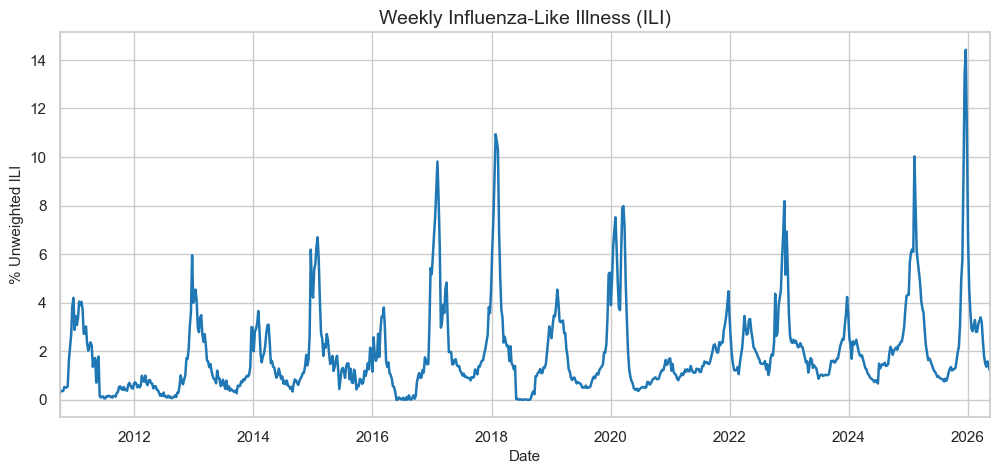

In [9]:
ax = ts_df["ili"].plot(color="#1f77b4", linewidth=1.8)
ax.set_title("Weekly Influenza-Like Illness (ILI)")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
plt.show()

## 5. Project Track and Forecasting Setup

This notebook follows **Track 3: Applied Forecasting Project** from the final project guidelines.

Main decisions:
- Target series: weekly `%UNWEIGHTED ILI`, stored as `ili`.
- Forecasting horizon: the final **52 weeks** are held out as the test set.
- Validation rule: chronological train/test split only; no random shuffling.
- Required methods covered below: decomposition, stationarity testing, ACF/PACF before and after differencing, at least two forecasting models, confidence intervals, error metrics, and residual diagnostics.

In [10]:
from math import sqrt

from scipy.stats import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

SEASONAL_PERIOD = 52
TEST_SIZE = 52

y = ts_df["ili"].copy()
train = y.iloc[:-TEST_SIZE]
test = y.iloc[-TEST_SIZE:]

print(f"Training period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} weeks)")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()} ({len(test)} weeks)")

Training period: 2010-10-01 to 2025-05-16 (764 weeks)
Test period:     2025-05-23 to 2026-05-15 (52 weeks)


## 6. Decomposition

The final project requires separating the series into trend, seasonal, and residual components. Because this is weekly influenza data, a natural seasonal period is 52 weeks.

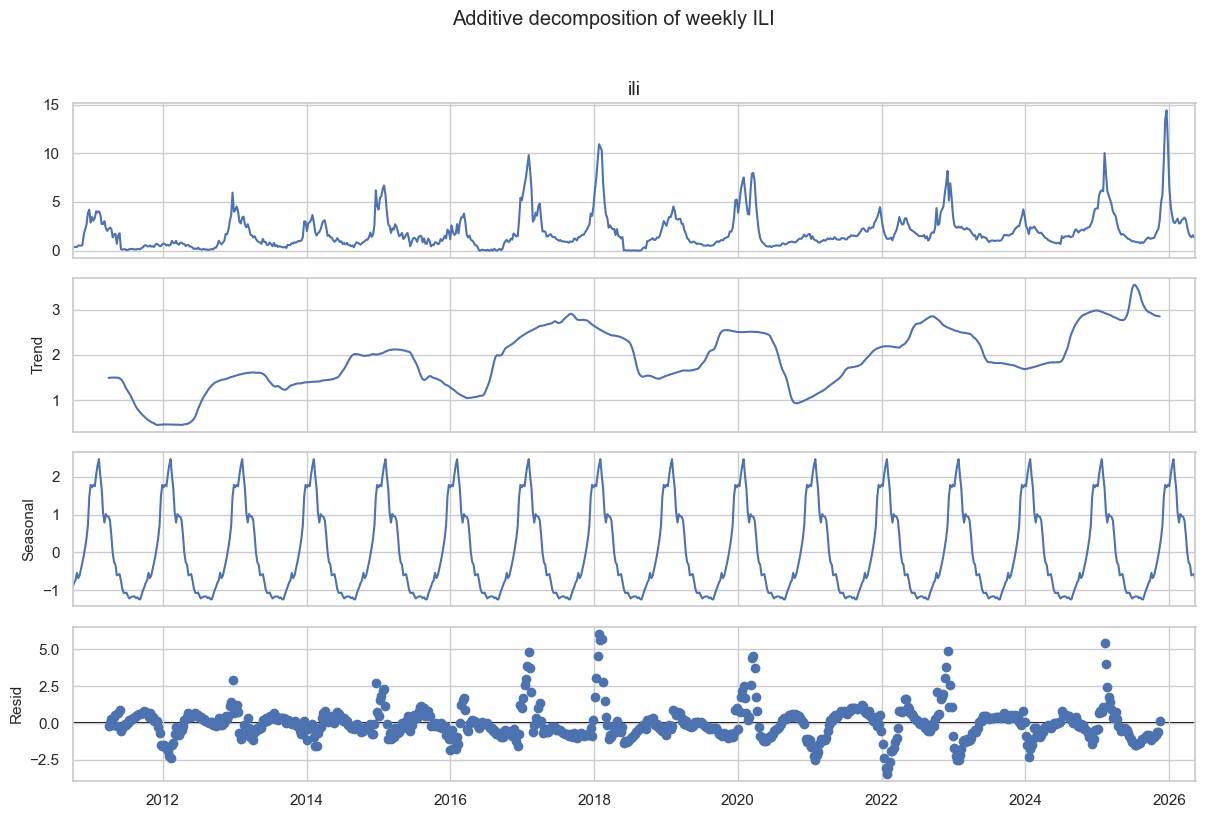

In [11]:
decomposition = seasonal_decompose(y, model="additive", period=SEASONAL_PERIOD)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Additive decomposition of weekly ILI", y=1.02)
plt.tight_layout()
plt.show()

## 7. Stationarity Tests

We use the Augmented Dickey-Fuller test. The null hypothesis is that the series has a unit root, meaning it is non-stationary. A small p-value gives evidence against the null.

In [12]:
def adf_summary(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return pd.Series({
        "series": name,
        "adf_statistic": result[0],
        "p_value": result[1],
        "used_lags": result[2],
        "n_obs": result[3],
        "stationary_at_5pct": result[1] < 0.05,
    })

first_diff = y.diff()
seasonal_diff = y.diff(SEASONAL_PERIOD)
seasonal_first_diff = y.diff(SEASONAL_PERIOD).diff()

adf_results = pd.DataFrame([
    adf_summary(y, "Original ILI"),
    adf_summary(first_diff, "First difference"),
    adf_summary(seasonal_diff, "Seasonal difference lag 52"),
    adf_summary(seasonal_first_diff, "Seasonal + first difference"),
])

adf_results

,series,adf_statistic,p_value,used_lags,n_obs,stationary_at_5pct
0,Original ILI,-7.128895,3.560215e-10,14,801,True
1,First difference,-11.030675,5.678778e-20,8,806,True
2,Seasonal difference lag 52,-5.444172,2.733945e-06,9,754,True
3,Seasonal + first difference,-12.604694,1.705984e-23,8,754,True


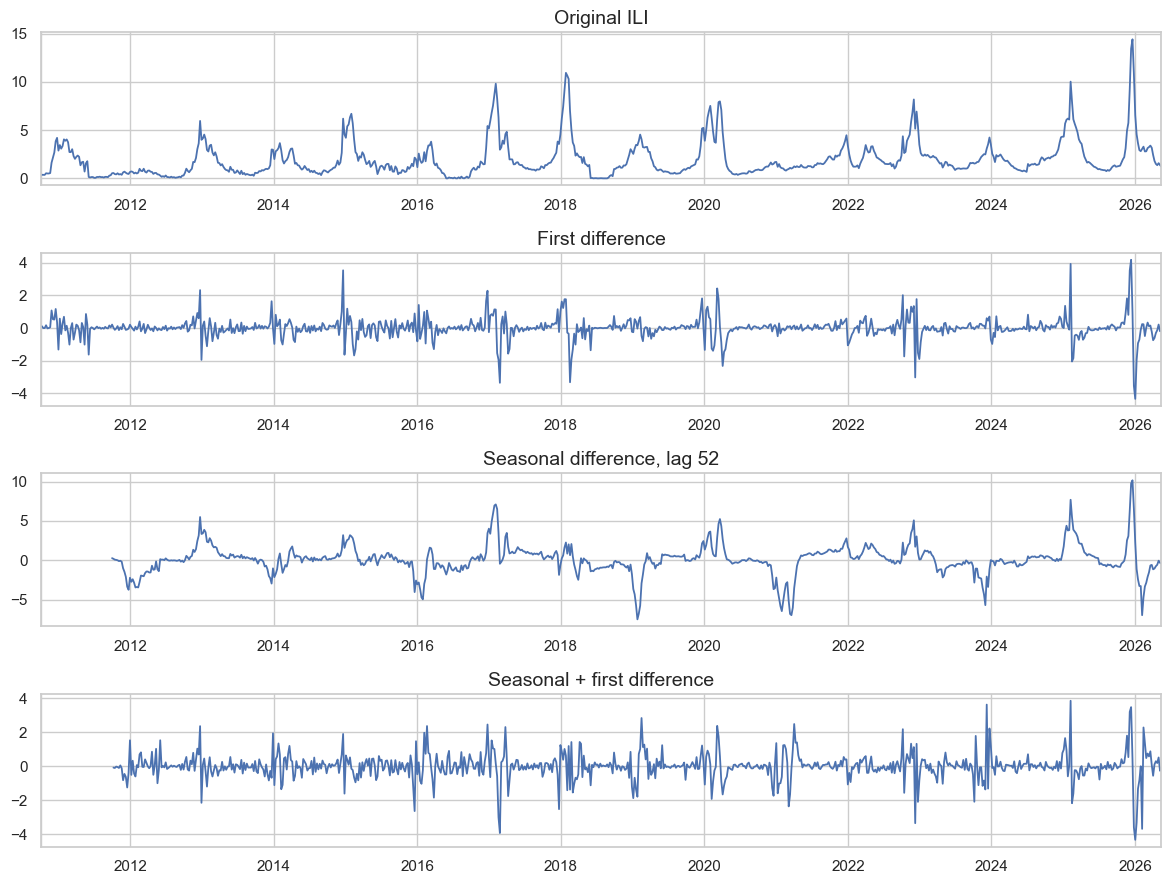

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=False)

series_to_plot = [
    (y, "Original ILI"),
    (first_diff, "First difference"),
    (seasonal_diff, "Seasonal difference, lag 52"),
    (seasonal_first_diff, "Seasonal + first difference"),
]

for ax, (series, title) in zip(axes, series_to_plot):
    series.plot(ax=ax, linewidth=1.3)
    ax.set_title(title)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## 8. ACF and PACF Before and After Differencing

ACF/PACF plots are used to inspect persistence, seasonality, and possible AR/MA orders. The dashed confidence bands are a visual guide only; the final interpretation should be checked manually.

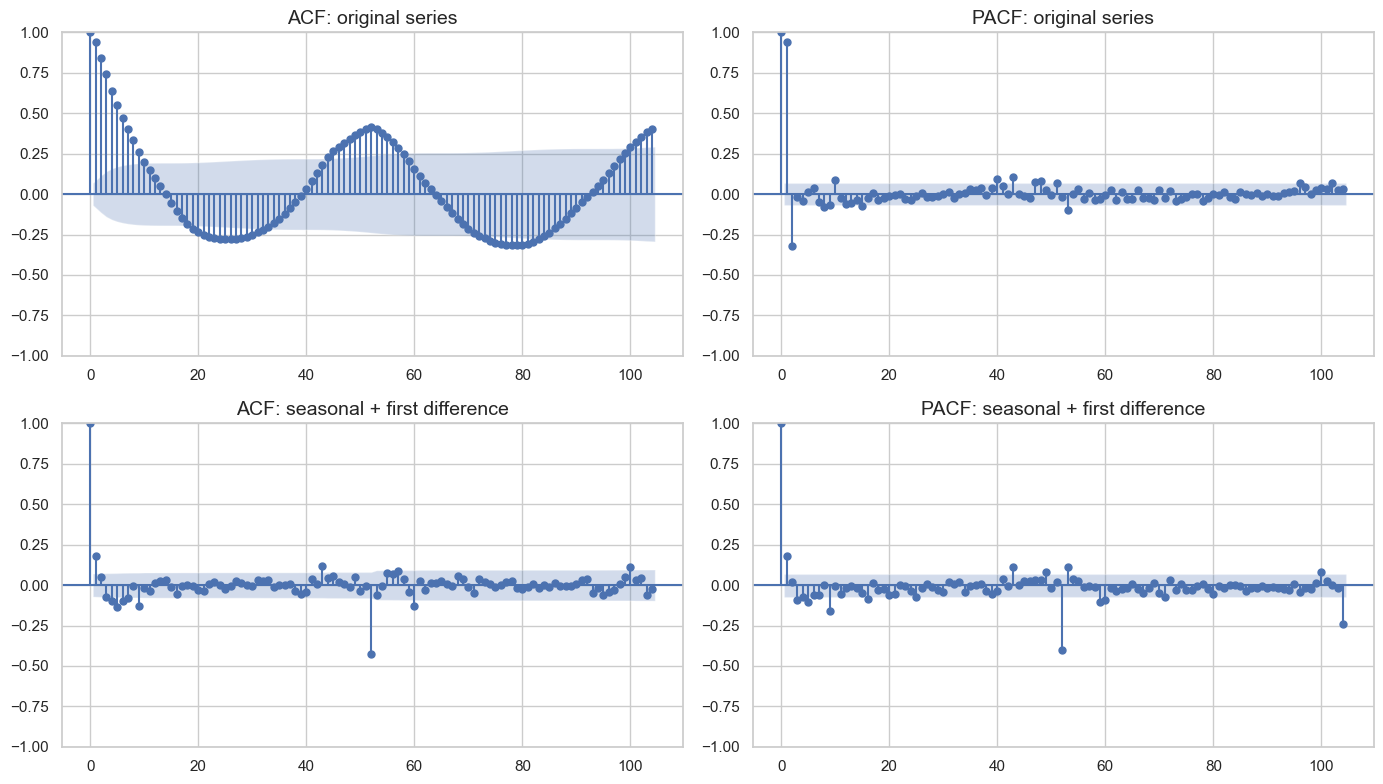

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(y.dropna(), lags=104, ax=axes[0, 0])
axes[0, 0].set_title("ACF: original series")

plot_pacf(y.dropna(), lags=104, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF: original series")

plot_acf(seasonal_first_diff.dropna(), lags=104, ax=axes[1, 0])
axes[1, 0].set_title("ACF: seasonal + first difference")

plot_pacf(seasonal_first_diff.dropna(), lags=104, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF: seasonal + first difference")

plt.tight_layout()
plt.show()

## 9. Evaluation Metrics

The project guidelines require MAE, RMSE, and MAPE. MAPE is easy to interpret as a percentage, but it can be unstable when actual values are close to zero.

In [15]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    non_zero = y_true != 0
    return (np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero]).mean()) * 100


def evaluate_forecast(y_true, y_pred, model_name):
    y_pred = pd.Series(y_pred, index=y_true.index)
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred),
    }

## 10. Model 1: Seasonal Naive Baseline

The seasonal naive model forecasts each week using the observed value from the same week in the previous year. This is a strong baseline for seasonal epidemiological data.

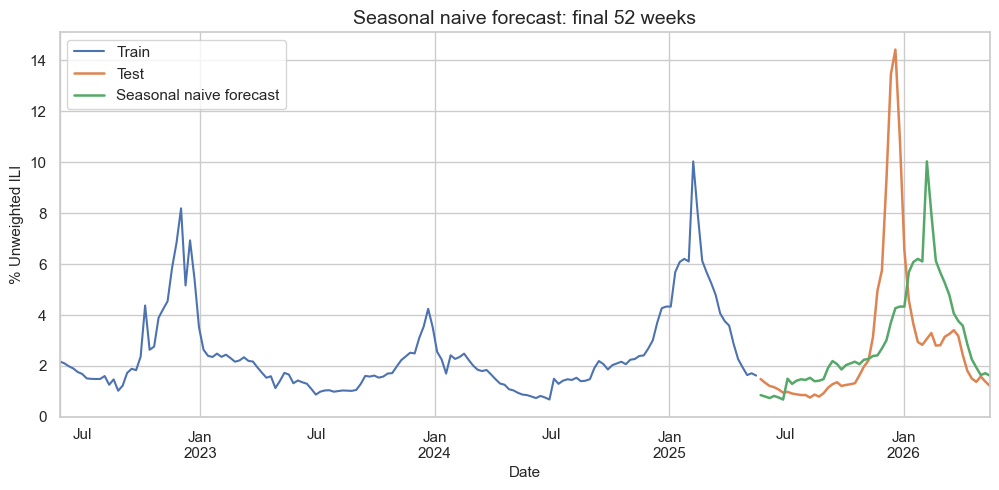

In [16]:
seasonal_naive_forecast = y.shift(SEASONAL_PERIOD).loc[test.index]

ax = train.iloc[-156:].plot(label="Train", figsize=(12, 5), linewidth=1.5)
test.plot(ax=ax, label="Test", linewidth=1.8)
seasonal_naive_forecast.plot(ax=ax, label="Seasonal naive forecast", linewidth=1.8)
ax.set_title("Seasonal naive forecast: final 52 weeks")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
ax.legend()
plt.show()

## 11. Model 2: Holt-Winters Exponential Smoothing

Holt-Winters captures level, trend, and seasonality. We use additive seasonality because the ILI series can be low and multiplicative seasonality requires strictly positive behavior without near-zero instability.

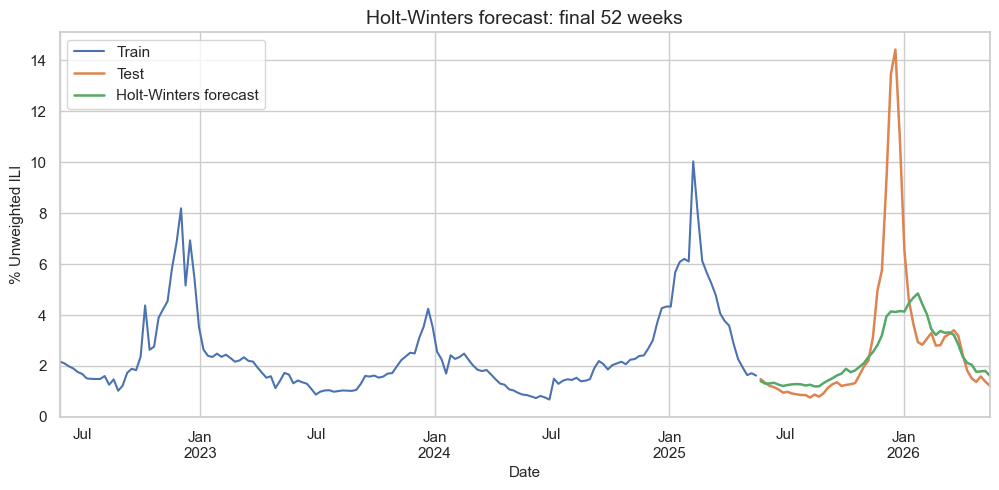

In [17]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated",
)

hw_result = hw_model.fit(optimized=True)
hw_forecast = hw_result.forecast(TEST_SIZE)

ax = train.iloc[-156:].plot(label="Train", figsize=(12, 5), linewidth=1.5)
test.plot(ax=ax, label="Test", linewidth=1.8)
hw_forecast.plot(ax=ax, label="Holt-Winters forecast", linewidth=1.8)
ax.set_title("Holt-Winters forecast: final 52 weeks")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
ax.legend()
plt.show()

## 12. Model 3: SARIMA

SARIMA extends ARIMA with seasonal AR and MA terms. Based on the yearly seasonality and the ACF/PACF inspection, we test a small manual candidate set instead of using automatic model selection.

In [18]:
sarima_candidates = [
    {"order": (1, 0, 1), "seasonal_order": (1, 1, 0, SEASONAL_PERIOD)},
    {"order": (2, 0, 1), "seasonal_order": (1, 1, 0, SEASONAL_PERIOD)},
    {"order": (1, 0, 1), "seasonal_order": (0, 1, 1, SEASONAL_PERIOD)},
    {"order": (1, 1, 1), "seasonal_order": (1, 0, 0, SEASONAL_PERIOD)},
]

sarima_rows = []
sarima_results = {}

for candidate in sarima_candidates:
    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]
    model_name = f"SARIMA{order}x{seasonal_order}"
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False, maxiter=80)
        forecast = result.get_forecast(steps=TEST_SIZE).predicted_mean
        row = evaluate_forecast(test, forecast, model_name)
        row["AIC"] = result.aic
        row["BIC"] = result.bic
        sarima_rows.append(row)
        sarima_results[model_name] = result
    except Exception as exc:
        sarima_rows.append({
            "model": model_name,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE (%)": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "error": str(exc),
        })

sarima_comparison = pd.DataFrame(sarima_rows).sort_values("AIC")
sarima_comparison

,model,MAE,RMSE,MAPE (%),AIC,BIC
2,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",1.070822,2.446834,25.207097,1191.589505,1209.546324
3,"SARIMA(1, 1, 1)x(1, 0, 0, 52)",1.458591,2.969237,46.360277,1238.441989,1256.703049
1,"SARIMA(2, 0, 1)x(1, 1, 0, 52)",1.246403,2.557644,33.117114,1273.806899,1296.252924
0,"SARIMA(1, 0, 1)x(1, 1, 0, 52)",1.265013,2.559809,34.868363,1280.621476,1298.584370


In [19]:
best_sarima_name = sarima_comparison.dropna(subset=["AIC"]).iloc[0]["model"]
best_sarima_result = sarima_results[best_sarima_name]

sarima_forecast_result = best_sarima_result.get_forecast(steps=TEST_SIZE)
sarima_forecast = sarima_forecast_result.predicted_mean
sarima_conf_int = sarima_forecast_result.conf_int()

print(f"Selected SARIMA model by lowest AIC: {best_sarima_name}")
best_sarima_result.summary()

Selected SARIMA model by lowest AIC: SARIMA(1, 0, 1)x(0, 1, 1, 52)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                ili   No. Observations:                  764
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 52)   Log Likelihood                -591.795
Date:                            Mon, 01 Jun 2026   AIC                           1191.590
Time:                                    22:28:56   BIC                           1209.546
Sample:                                10-01-2010   HQIC                          1198.551
                                     - 05-16-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8819      0.011     81.748      0.000       0.861       0.903
ma.L1          0.1707      0.024      7.187      0.000       0.124       0.217
ma.S.L52      -0.7496      0.025    -29.926      0.000      -0.799      -0.701
sigma2         0.3433      0.008     41.740      0.000       0.327       0.359
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):              2908.83
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               1.63   Skew:                             0.75
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

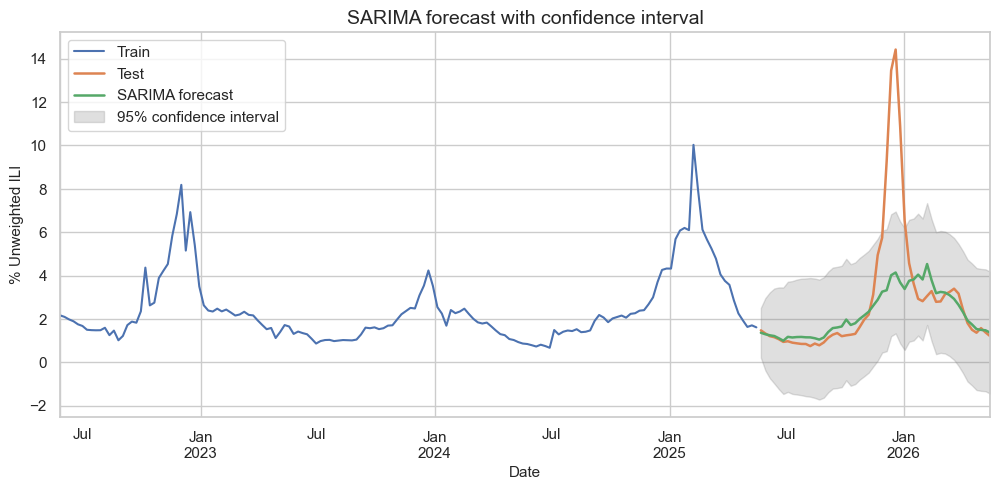

In [20]:
ax = train.iloc[-156:].plot(label="Train", figsize=(12, 5), linewidth=1.5)
test.plot(ax=ax, label="Test", linewidth=1.8)
sarima_forecast.plot(ax=ax, label="SARIMA forecast", linewidth=1.8)
ax.fill_between(
    sarima_conf_int.index,
    sarima_conf_int.iloc[:, 0],
    sarima_conf_int.iloc[:, 1],
    color="gray",
    alpha=0.25,
    label="95% confidence interval",
)
ax.set_title("SARIMA forecast with confidence interval")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
ax.legend()
plt.show()

## 13. Model Comparison on the Test Set

The final decision should consider both forecast accuracy and diagnostics. A model with a slightly better test error can still be problematic if residuals are strongly autocorrelated.

In [21]:
comparison_rows = [
    evaluate_forecast(test, seasonal_naive_forecast, "Seasonal naive"),
    evaluate_forecast(test, hw_forecast, "Holt-Winters additive"),
    evaluate_forecast(test, sarima_forecast, best_sarima_name),
]

model_comparison = pd.DataFrame(comparison_rows).sort_values("RMSE")
model_comparison

,model,MAE,RMSE,MAPE (%)
1,Holt-Winters additive,1.095516,2.390432,29.934066
2,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",1.070822,2.446834,25.207097
0,Seasonal naive,1.776603,2.910443,58.632623


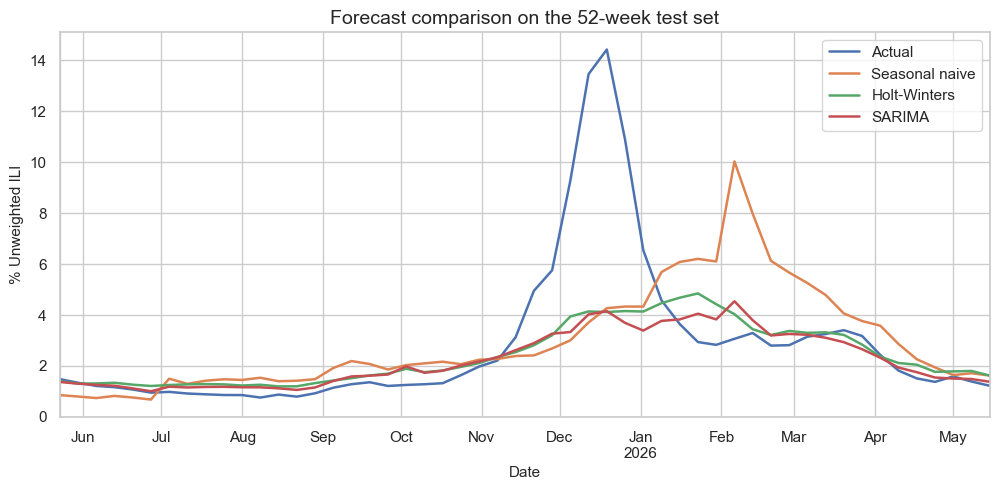

In [22]:
forecast_plot_df = pd.DataFrame({
    "Actual": test,
    "Seasonal naive": seasonal_naive_forecast,
    "Holt-Winters": hw_forecast,
    "SARIMA": sarima_forecast,
})

ax = forecast_plot_df.plot(figsize=(12, 5), linewidth=1.8)
ax.set_title("Forecast comparison on the 52-week test set")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
plt.show()

## 14. SARIMA Coefficient Interpretation

For the mini-defense, focus on the sign and magnitude of AR and MA coefficients:
- Positive AR terms mean high ILI values tend to be followed by high ILI values after the corresponding lag.
- MA terms describe how current forecasts adjust after previous forecast errors.
- Seasonal AR/MA terms describe yearly dependence around lag 52.

In [23]:
coef_table = pd.DataFrame({
    "coefficient": best_sarima_result.params,
    "p_value": best_sarima_result.pvalues,
})
coef_table

,coefficient,p_value
ar.L1,0.881945,0.000000e+00
ma.L1,0.170657,6.621716e-13
ma.S.L52,-0.749615,9.079549e-197
sigma2,0.343314,0.000000e+00


## 15. Residual Diagnostics

The final project requires checking whether residuals behave like white noise. We inspect residual plots, residual ACF, Ljung-Box p-values, and a normality check.

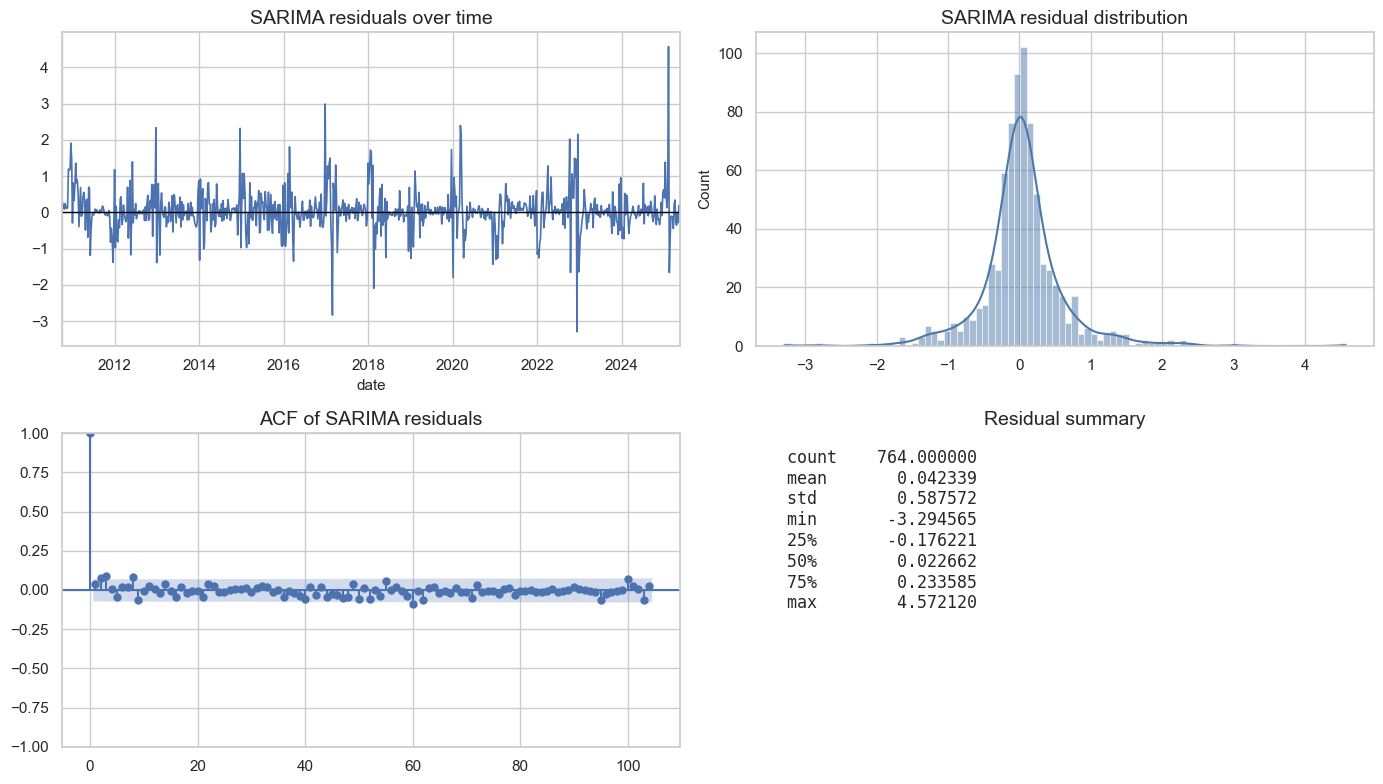

In [24]:
sarima_residuals = best_sarima_result.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sarima_residuals.plot(ax=axes[0, 0], linewidth=1.2)
axes[0, 0].set_title("SARIMA residuals over time")
axes[0, 0].axhline(0, color="black", linewidth=1)

sns.histplot(sarima_residuals, kde=True, ax=axes[0, 1], color="#4c78a8")
axes[0, 1].set_title("SARIMA residual distribution")

plot_acf(sarima_residuals, lags=104, ax=axes[1, 0])
axes[1, 0].set_title("ACF of SARIMA residuals")

stats = pd.Series(sarima_residuals).describe()
axes[1, 1].axis("off")
axes[1, 1].text(0.05, 0.95, stats.to_string(), va="top", family="monospace")
axes[1, 1].set_title("Residual summary")

plt.tight_layout()
plt.show()

In [25]:
ljung_box = acorr_ljungbox(sarima_residuals, lags=[12, 26, 52], return_df=True)
ljung_box

,lb_stat,lb_pvalue
12,21.858718,0.039134
26,28.784489,0.320973
52,51.370884,0.498581


In [26]:
jb_stat, jb_pvalue = jarque_bera(sarima_residuals)
print(f"Jarque-Bera statistic: {jb_stat:.3f}")
print(f"Jarque-Bera p-value:   {jb_pvalue:.4f}")

if (ljung_box["lb_pvalue"] > 0.05).all():
    print("Ljung-Box result: no strong evidence of residual autocorrelation at the tested lags.")
else:
    print("Ljung-Box result: residual autocorrelation may remain at one or more tested lags.")

Jarque-Bera statistic: 2581.465
Jarque-Bera p-value:   0.0000
Ljung-Box result: residual autocorrelation may remain at one or more tested lags.


## 16. Final Forecast Beyond the Observed Data

After evaluating models on the holdout period, we refit the selected SARIMA model on the full available series and forecast the next 52 weeks with confidence intervals.

In [27]:
selected_order = best_sarima_result.model.order
selected_seasonal_order = best_sarima_result.model.seasonal_order

final_sarima_model = SARIMAX(
    y,
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_sarima_result = final_sarima_model.fit(disp=False, maxiter=80)

future_forecast_result = final_sarima_result.get_forecast(steps=52)
future_forecast = future_forecast_result.predicted_mean
future_conf_int = future_forecast_result.conf_int()

forecast_table = pd.DataFrame({
    "forecast_ili": future_forecast,
    "lower_95": future_conf_int.iloc[:, 0],
    "upper_95": future_conf_int.iloc[:, 1],
})

forecast_table.head(10)

,forecast_ili,lower_95,upper_95
2026-05-22,1.033709,-0.179424,2.246841
2026-05-29,0.991038,-0.840482,2.822558
2026-06-05,0.962557,-1.220681,3.145795
2026-06-12,0.958973,-1.454647,3.372593
2026-06-19,0.888253,-1.684649,3.461156
2026-06-26,0.798949,-1.887222,3.485121
2026-07-03,0.963040,-1.805043,3.731122
2026-07-10,0.944654,-1.883304,3.772613
2026-07-17,0.969398,-1.902648,3.841443
2026-07-24,0.981814,-1.922857,3.886486


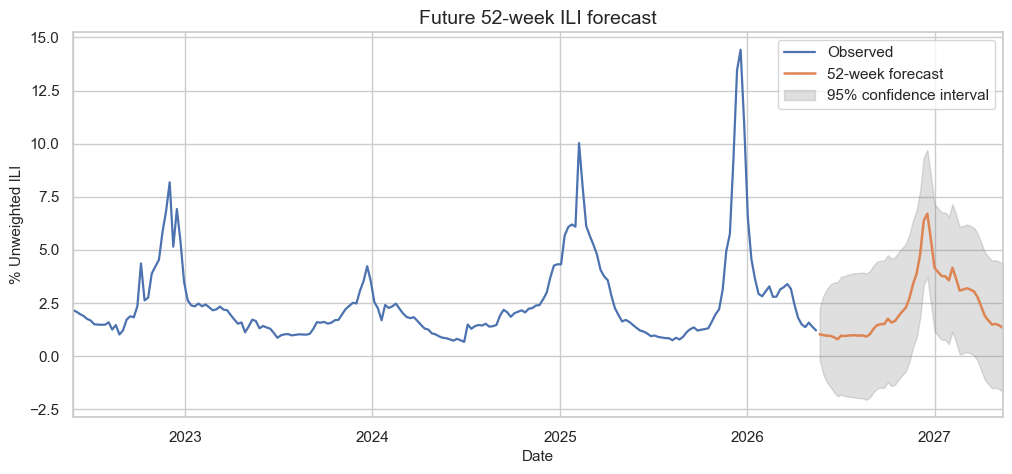

In [28]:
ax = y.iloc[-208:].plot(label="Observed", figsize=(12, 5), linewidth=1.6)
future_forecast.plot(ax=ax, label="52-week forecast", linewidth=1.8)
ax.fill_between(
    future_conf_int.index,
    future_conf_int.iloc[:, 0],
    future_conf_int.iloc[:, 1],
    color="gray",
    alpha=0.25,
    label="95% confidence interval",
)
ax.set_title("Future 52-week ILI forecast")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
ax.legend()
plt.show()

## 17. Interpretation Checklist for the Report

Use the executed outputs above to fill in the final report:
- Describe the dataset source, target variable, date normalization, and forecasting horizon.
- Explain whether the raw series appears seasonal and whether differencing improves stationarity.
- Interpret the ACF/PACF plots manually before choosing AR and MA orders.
- Compare at least two models using MAE, RMSE, and MAPE on the test set only.
- Discuss whether SARIMA residuals look like white noise according to plots and Ljung-Box tests.
- Explain the uncertainty interval and the risk of overconfidence in epidemiological forecasting.
- Mention limitations: single-region univariate data, reporting changes, outliers, and post-pandemic behavior shifts.